#  Spam Mail Detection using Machine Learning

## Objective

The objective of this project is to develop a machine learning model that can classify SMS messages as **Spam** or **Ham** using Natural Language Processing (NLP) techniques.

The project involves data preprocessing, feature extraction using **TF-IDF Vectorization**, model training using the **Multinomial Naive Bayes** algorithm, and evaluation using multiple performance metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.


# Step 1: Import Required Libraries

In this step, we import all the Python libraries required for data manipulation, visualization, text preprocessing, feature extraction, model training, and model evaluation.


In [67]:
import pandas as pd

# Step 2: Load the Dataset

The SMS Spam Collection dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.


In [68]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [69]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Step 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure of the dataset, identify missing values, inspect class distribution, and gain useful insights before preprocessing the data.

In [70]:
df.shape

(5572, 5)

In [71]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [73]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [74]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


In [75]:
import matplotlib.pyplot as plt

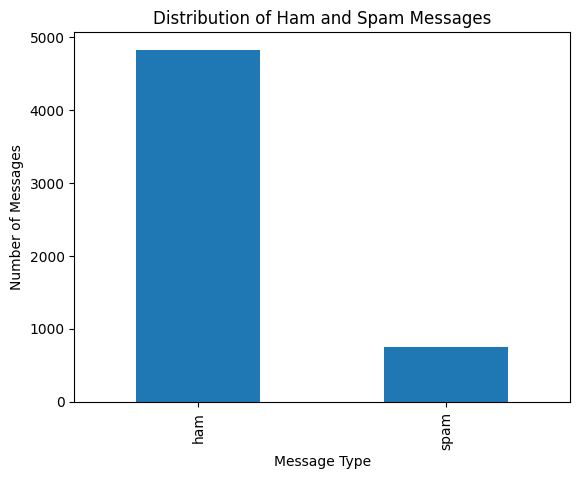

In [76]:
df["v1"].value_counts().plot(kind="bar")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [77]:
df["message_length"] = df["v2"].apply(len)

In [78]:
df.groupby("v1")["message_length"].mean()

,message_length
v1,
ham,71.023627
spam,138.866131


In [79]:
df["message_length"].describe()

,message_length
count,5572.000000
mean,80.118808
std,59.690841
min,2.000000
25%,36.000000
50%,61.000000
75%,121.000000
max,910.000000


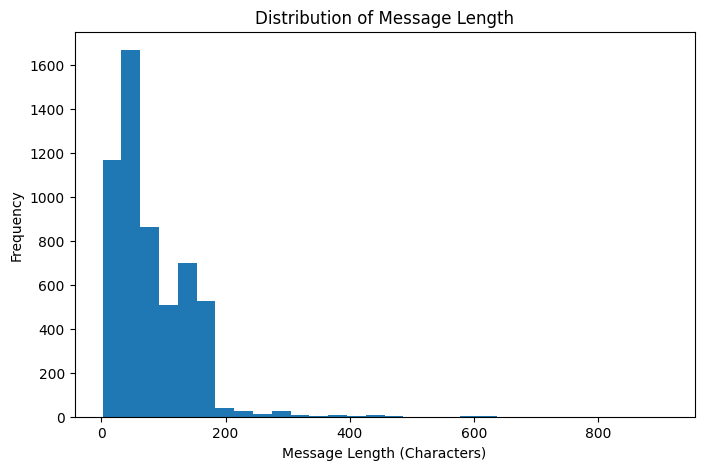

In [80]:
plt.figure(figsize=(8,5))

plt.hist(df["message_length"], bins=30)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length (Characters)")
plt.ylabel("Frequency")

plt.show()

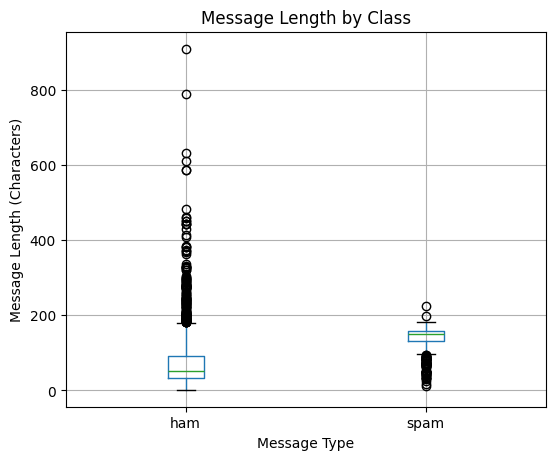

In [81]:
import matplotlib.pyplot as plt

df.boxplot(column="message_length", by="v1", figsize=(6,5))

plt.title("Message Length by Class")
plt.suptitle("")   # Removes the extra default title
plt.xlabel("Message Type")
plt.ylabel("Message Length (Characters)")

plt.show()

# Step 4: Data Cleaning

The dataset is cleaned by removing unnecessary columns, renaming column names for better readability, checking for missing values, and converting categorical labels into numerical values suitable for machine learning.


In [82]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [83]:
df.rename(columns={
    "v1": "label",
    "v2": "message"
}, inplace=True)

In [84]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Step 5: Text Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). In this stage, the text is converted to lowercase, punctuation is removed, stopwords are eliminated, and the messages are tokenized to prepare the data for feature extraction.


In [85]:
df["message"] = df["message"].str.lower()

In [86]:
import string

In [87]:
df["message"] = df["message"].apply(
    lambda text: "".join(char for char in text if char not in string.punctuation)
)

In [88]:
df.head()

,label,message,message_length
0,0,go until jurong point crazy available only in ...,111
1,0,ok lar joking wif u oni,29
2,1,free entry in 2 a wkly comp to win fa cup fina...,155
3,0,u dun say so early hor u c already then say,49
4,0,nah i dont think he goes to usf he lives aroun...,61


In [89]:
import nltk

In [90]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [91]:
from nltk.corpus import stopwords

In [92]:
stopwords.words("english")[:20]

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been']

In [93]:
from nltk.tokenize import word_tokenize

In [94]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [95]:
df["tokens"] = df["message"].apply(word_tokenize)

In [96]:
df[["message", "tokens"]].head()

,message,tokens
0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


# Step 6: Feature Extraction using TF-IDF

Machine learning algorithms cannot understand raw text directly. Therefore, the cleaned text is converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.


In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [98]:
tfidf = TfidfVectorizer()

In [99]:
X = tfidf.fit_transform(df["message"])

In [100]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


In [101]:
X.shape

(5572, 9489)

# Step 7: Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.


In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["label"],
    test_size=0.2,
    random_state=42
)

In [104]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4457, 9489)
X_test shape: (1115, 9489)
y_train shape: (4457,)
y_test shape: (1115,)


# Step 8: Model Training

A Multinomial Naive Bayes classifier is trained using the TF-IDF feature vectors. This algorithm is widely used for text classification tasks due to its simplicity and effectiveness.


In [105]:
from sklearn.naive_bayes import MultinomialNB

In [106]:
model = MultinomialNB()

In [107]:
model.fit(X_train, y_train)

MultinomialNB()

In [108]:
y_pred = model.predict(X_test)

# Step 9: Model Evaluation

The trained model is evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix to assess its performance on unseen SMS messages.


In [109]:
from sklearn.metrics import accuracy_score

In [110]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.95695067264574


In [111]:
from sklearn.metrics import classification_report

In [112]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       965
           1       1.00      0.68      0.81       150

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [113]:
from sklearn.metrics import confusion_matrix

In [114]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[965   0]
 [ 48 102]]


In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

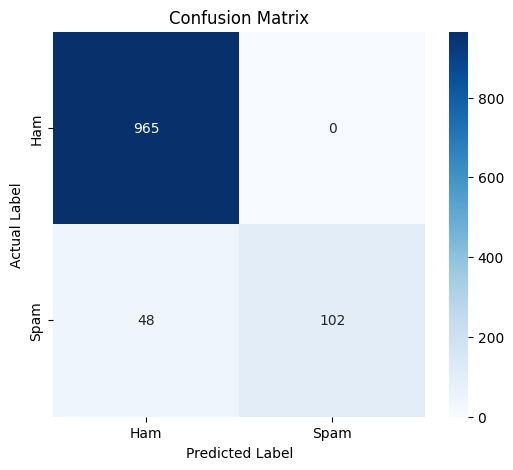

In [116]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Step 10: Interactive Spam Prediction

A reusable prediction function is created to classify user-provided SMS messages as **Spam** or **Ham**. The user can enter multiple messages interactively until choosing to exit the program.


In [117]:
def predict_spam(message):
    """
    Predict whether a message is Spam or Ham.
    """

    # Convert message into TF-IDF features
    message_tfidf = tfidf.transform([message])

    # Predict
    prediction = model.predict(message_tfidf)

    print("\nMessage:")
    print(message)

    print("\nPrediction:")

    if prediction[0] == 1:
        print("🚨 This message is classified as SPAM.")
    else:
        print("📩 This message is classified as HAM.")

In [ ]:
while True:

    message = input("Enter your message (type 'exit' to quit): ")

    if message.lower() == "exit":
        print("Program Ended.")
        break

    predict_spam(message)
    print("-" * 40)


Message:
hey, we have a meeting today.

Prediction:
📩 This message is classified as HAM.
----------------------------------------
Enter your message (type 'exit' to quit): you won a loteryyyy!!!!!!

Message:
you won a loteryyyy!!!!!!

Prediction:
🚨 This message is classified as SPAM.
----------------------------------------


# Conclusion

In this project, a Spam Mail Detection system was successfully developed using **Natural Language Processing (NLP)** and **Machine Learning** techniques. The SMS Spam Collection dataset was preprocessed through text cleaning, lowercasing, punctuation removal, stopword removal, and TF-IDF vectorization to convert textual data into numerical features.

A **Multinomial Naive Bayes** classifier was trained on the processed dataset and achieved an accuracy of approximately **95.7%**, demonstrating strong performance in classifying SMS messages as Spam or Ham. The model was further evaluated using a Classification Report and Confusion Matrix, which provided insights into its precision, recall, and overall predictive performance.

Finally, an interactive prediction function was implemented, allowing users to enter their own SMS messages and instantly determine whether they are classified as **Spam** or **Ham**. This project demonstrates the practical application of machine learning for text classification and provides a simple yet effective solution for spam message detection.
